Importing libaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Importing Dataset

In [2]:
dataset = pd.read_csv("auto-mpg.csv")
numeric_dataset = dataset.select_dtypes(include=[np.number])
correlation = numeric_dataset.corr()["mpg"].sort_values(ascending=False)


features = ["weight", "displacement", "cylinders", "model year", "origin"]
target = "mpg"

x = dataset[features]
y = dataset[target]

Spliting the Dataset into Training set and Test set

In [3]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

Traning Linear Regression Model

In [5]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[-5.66, 0.8 ,-0.17, 2.92, 0.96]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,23.61
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[33.23,16.43,13.04, 5.8 , 3.5 ]"


Training Polynomial Regression Model

In [6]:
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2)
x_train_poly = poly_reg.fit_transform(x_train)
x_test_poly = poly_reg.transform(x_test)

poly_model = LinearRegression()
poly_model.fit(x_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 0. ,-5.3 ,-2.48,..., 0.85, 0.15,-0.96]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.59
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,20
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](21,)","[49.91,33.08,28.04,..., 1.33, 0.8 , 0. ]"


Model Evaluation

In [7]:
from sklearn.metrics import r2_score, mean_squared_error
#Linear Regression results
lin_pred = lin_reg.predict(x_test)
lin_r2 = r2_score(y_test, lin_pred)
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_pred))

#Polynomial Regression results
poly_pred = poly_model.predict(x_test_poly)
poly_r2 = r2_score(y_test, poly_pred)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_pred))

print("LinearRegression")
print(f"  R2 Score: {lin_r2:.4f}")
print(f"  RMSE: {lin_rmse:.4f}")

print("\nPolynomialRegression")
print(f"  R2 Score: {poly_r2:.4f}")
print(f"  RMSE: {poly_rmse:.4f}")

LinearRegression
  R2 Score: 0.8435
  RMSE: 2.9005

PolynomialRegression
  R2 Score: 0.8667
  RMSE: 2.6772


Visualizing Linear Regression result

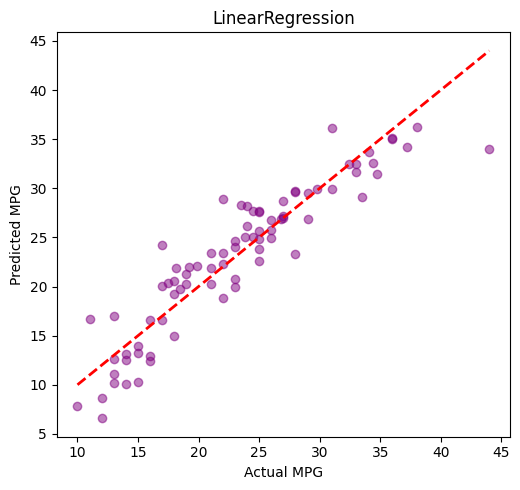

In [8]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_test, lin_pred, color="purple", alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("LinearRegression")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.tight_layout()
plt.show()

Visualizing Polynomial Regression result

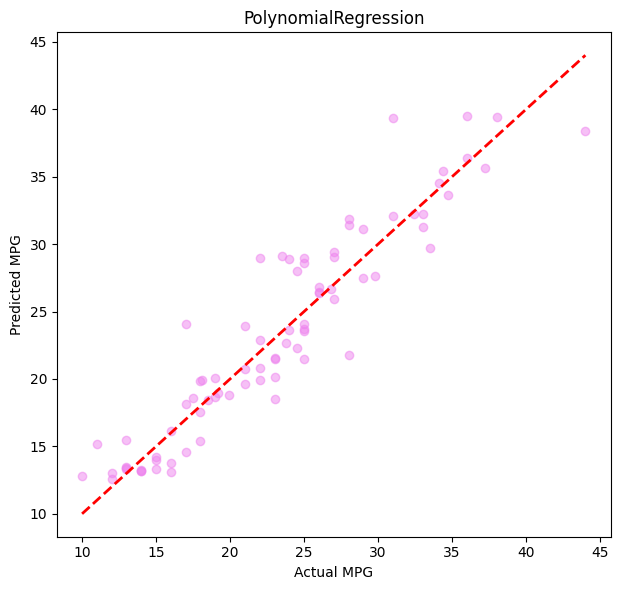

In [9]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(y_test, poly_pred, color="violet", alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.title("PolynomialRegression")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.tight_layout()
plt.show()

Model Comparison

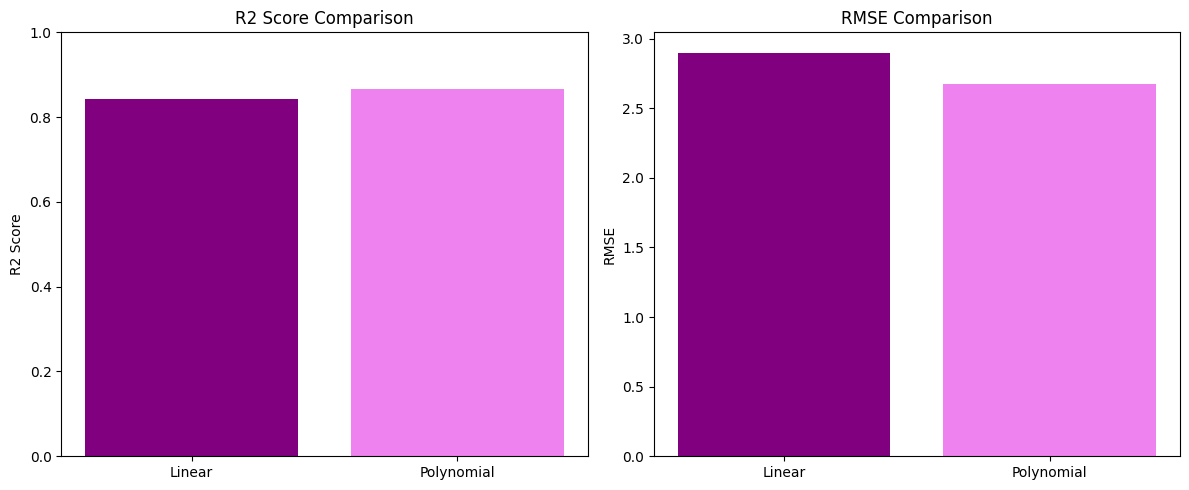

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#R2 Score Comparsion
axes[0].bar(["Linear", "Polynomial"], [lin_r2, poly_r2], color=["purple", "violet"])
axes[0].set_title("R2 Score Comparison")
axes[0].set_ylabel("R2 Score")
axes[0].set_ylim(0, 1)

#RMSE Comparison
axes[1].bar(["Linear", "Polynomial"], [lin_rmse, poly_rmse], color=["purple", "violet"])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")

plt.tight_layout()
plt.show()